# Student Performance Prediction using ANN

## Project Introduction

In this project, we will predict student performance using an
Artificial Neural Network (ANN).

We will use:
- Study Hours
- Attendance
- Previous GPA
- Exam Score

The final prediction will show the student's performance level.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")
print("TensorFlow Version:", tf.__version__)

Libraries imported successfully!
TensorFlow Version: 2.21.0


## Load the Dataset

Now we load the student performance dataset using Pandas.

The CSV file should be present in the same folder as this notebook.

In [2]:
data = pd.read_csv("student_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", data.shape)

Dataset loaded successfully!
Dataset Shape: (500, 11)


In [3]:
data.head()

,student_id,name,age,city,course,daily_study_hours,attendance_percent,exam_score,enrollment_date,performance_level,study_efficiency
0,1,Henry_LY,22,Delhi,Data Science,6.89,97,73,2025-06-24,Good,10.595065
1,2,Eva_TV,18,Bangalore,Cyber Security,2.77,91,46,2025-06-12,Average,16.606498
2,3,Jack_RH,25,Hyderabad,Machine Learning,9.73,74,100,2025-10-28,Excellent,10.277492
3,4,Charlie_QC,18,Kolkata,Data Science,4.63,82,50,2025-12-02,Average,10.799136
4,5,Grace_WU,24,Pune,Data Science,1.94,71,5,2025-05-25,Poor,2.577320


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          500 non-null    int64  
 1   name                500 non-null    object 
 2   age                 500 non-null    int64  
 3   city                500 non-null    object 
 4   course              500 non-null    object 
 5   daily_study_hours   500 non-null    float64
 6   attendance_percent  500 non-null    int64  
 7   exam_score          500 non-null    int64  
 8   enrollment_date     500 non-null    object 
 9   performance_level   500 non-null    object 
 10  study_efficiency    500 non-null    float64
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB


In [5]:
print("Column Names:")
for column in data.columns:
    print(column)

Column Names:
student_id
name
age
city
course
daily_study_hours
attendance_percent
exam_score
enrollment_date
performance_level
study_efficiency


## Check Missing Values

Missing values can affect the performance of a machine learning
model, so we check them before training the model.

In [6]:
print(data.isnull().sum())

student_id            0
name                  0
age                   0
city                  0
course                0
daily_study_hours     0
attendance_percent    0
exam_score            0
enrollment_date       0
performance_level     0
study_efficiency      0
dtype: int64


In [7]:
data.describe()

,student_id,age,daily_study_hours,attendance_percent,exam_score,study_efficiency
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,24.302000,5.336480,80.990000,61.016000,12.800334
std,144.481833,3.648756,2.549064,11.743326,22.375905,4.569273
min,1.000000,18.000000,1.030000,60.000000,5.000000,2.577320
25%,125.750000,21.000000,3.132500,71.000000,44.000000,10.059557
50%,250.500000,24.000000,5.295000,81.500000,62.000000,11.559222
75%,375.250000,27.000000,7.380000,91.000000,79.000000,13.700614
max,500.000000,30.000000,9.960000,100.000000,100.000000,35.877863


## Select Important Features

For this project, we use four simple numerical features:

1. Study Hours
2. Attendance
3. Previous GPA
4. Exam Score

Using four features makes our ANN model simple and also makes
the Streamlit application easy to use.

In [11]:
import re

column_map = {
    re.sub(r"[^a-z0-9]", "", col.lower()): col
    for col in data.columns
}

def find_column(keywords):
    for normalized, original in column_map.items():
        if any(keyword in normalized for keyword in keywords):
            return original
    return None

study_col = find_column(["dailystudyhours", "studyhours", "studyhour"])
attendance_col = find_column(["attendance", "attendancepercent"])
study_efficiency_col = find_column(["studyefficiency", "efficiency"])
exam_col = find_column(["examscore", "exammarks", "score"])

print("Study Hours :", study_col)
print("Attendance  :", attendance_col)
print("Study Efficiency:", study_efficiency_col)
print("Exam Score  :", exam_col)

Study Hours : daily_study_hours
Attendance  : attendance_percent
Study Efficiency: study_efficiency
Exam Score  : exam_score


## Verify Selected Features

This cell checks whether all four required features were found
in our dataset.

If any feature shows None, stop and check the column names.

In [12]:
selected_features = [
    study_col,
    attendance_col,
    study_efficiency_col,
    exam_col
]

if None in selected_features:
    print("One or more required columns were not found.")
else:
    print("All 4 features found successfully!")
    print("Selected Features:", selected_features)

All 4 features found successfully!
Selected Features: ['daily_study_hours', 'attendance_percent', 'study_efficiency', 'exam_score']


## Create X and y

X contains our input features.

y contains the target column, performance_level.

The ANN will learn the relationship between X and y.

In [13]:
X = data[selected_features].copy()
y = data["performance_level"].copy()

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   daily_study_hours  attendance_percent  study_efficiency  exam_score
0               6.89                  97         10.595065          73
1               2.77                  91         16.606498          46
2               9.73                  74         10.277492         100
3               4.63                  82         10.799136          50
4               1.94                  71          2.577320           5

Target:
0         Good
1      Average
2    Excellent
3      Average
4         Poor
Name: performance_level, dtype: object


## Check Performance Classes

Let's check the different performance levels available
in the target column.

In [15]:
print("Performance Levels:")
print(y.unique())

print("\nNumber of Classes:", y.nunique())

Performance Levels:
['Good' 'Average' 'Excellent' 'Poor']

Number of Classes: 4


## Visualize Performance Levels

A count plot shows the number of students in each
performance level.

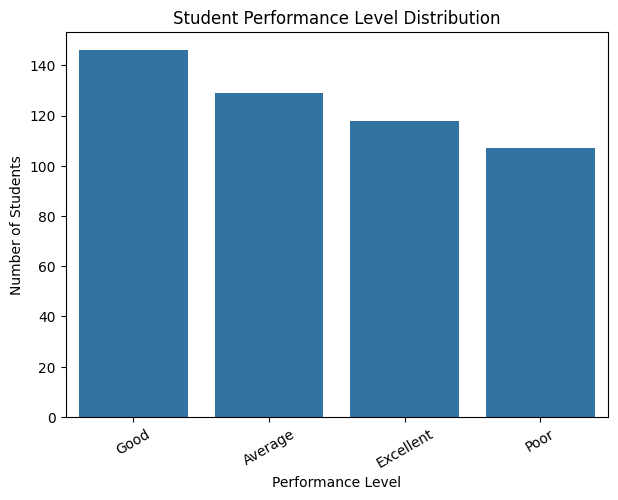

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y)

plt.title("Student Performance Level Distribution")
plt.xlabel("Performance Level")
plt.ylabel("Number of Students")

plt.xticks(rotation=30)
plt.show()

## Encode the Target Variable

Machine learning models work with numerical values.

LabelEncoder converts the performance levels into numbers.

In [17]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

print("\nEncoded Values:")
print(y_encoded[:10])

Classes:
['Average' 'Excellent' 'Good' 'Poor']

Encoded Values:
[2 0 1 0 3 1 3 0 0 2]


## Split the Dataset

We divide the dataset into:

- 80% Training Data
- 20% Testing Data

Training data is used to train the ANN.
Testing data is used to evaluate the ANN.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (400, 4)
Testing Data : (100, 4)


## Feature Scaling

Our features have different ranges.

For example, attendance may be from 0 to 100,
while GPA may be from 0 to 10.

StandardScaler converts the features into a similar scale.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


## Check Number of Features and Classes

We find the number of input features and output classes.
These values are required while creating the ANN.

In [20]:
number_of_features = X_train_scaled.shape[1]
number_of_classes = len(np.unique(y_encoded))

print("Number of Features:", number_of_features)
print("Number of Classes :", number_of_classes)

Number of Features: 4
Number of Classes : 4


## Build the Artificial Neural Network

Our ANN contains:

- Input Layer
- Hidden Layer with 16 neurons
- Hidden Layer with 8 neurons
- Output Layer

ReLU is used in hidden layers and Softmax is used in
the output layer.

In [21]:
model = Sequential([
    keras.Input(shape=(number_of_features,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(number_of_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile the ANN Model

We use:

- Adam optimizer
- Sparse Categorical Crossentropy loss
- Accuracy as the evaluation metric

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


## Train the ANN Model

Now we train our ANN using the training data.

The model will learn patterns from the student data.

In [23]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.1937 - loss: 1.4273 - val_accuracy: 0.2000 - val_loss: 1.3711
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3219 - loss: 1.3130 - val_accuracy: 0.3375 - val_loss: 1.2899
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3875 - loss: 1.2430 - val_accuracy: 0.3625 - val_loss: 1.2244
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4281 - loss: 1.1769 - val_accuracy: 0.4125 - val_loss: 1.1565
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4500 - loss: 1.1085 - val_accuracy: 0.5250 - val_loss: 1.0786
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5500 - loss: 1.0261 - val_accuracy: 0.6125 - val_loss: 0.9873
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5969 - loss: 0.9286 - val_accuracy: 0.6625 - val_loss: 0.8959
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6625 - loss: 0.8497 - val_accuracy: 0.6250 - val_loss

## Evaluate the Model

Now we test the trained ANN using the unseen testing data.

This gives us the test loss and test accuracy.

In [24]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Accuracy Percentage:", test_accuracy * 100, "%")

Test Loss: 0.19499903917312622
Test Accuracy: 0.9300000071525574
Accuracy Percentage: 93.00000071525574 %


## Training and Validation Accuracy

This graph shows how the model accuracy changes during training.

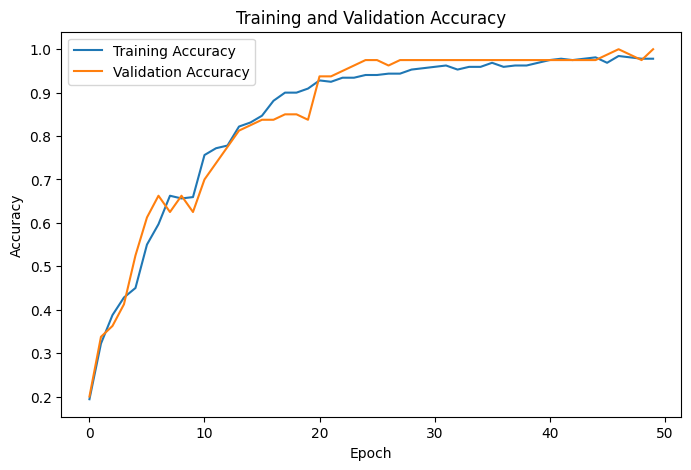

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Training and Validation Loss

This graph shows the loss of the model during training.

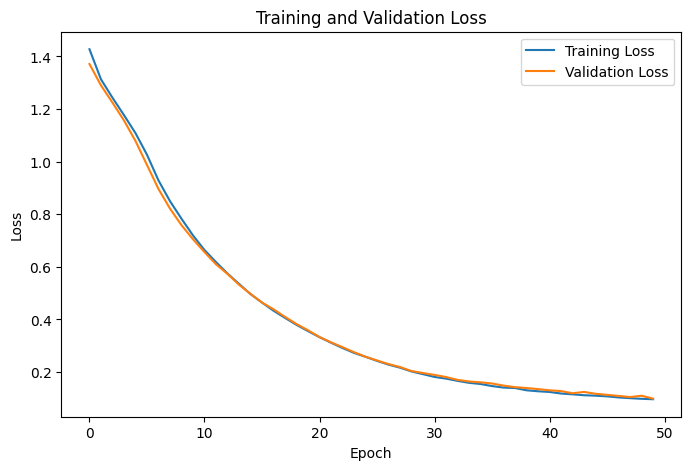

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Make Predictions

Now we use the trained ANN to predict the performance
of the test students.

In [27]:
predictions = model.predict(X_test_scaled, verbose=0)

predicted_classes = np.argmax(predictions, axis=1)

print("Predicted Classes:")
print(predicted_classes[:10])

print("\nActual Classes:")
print(y_test[:10])

Predicted Classes:
[3 1 1 2 2 3 2 2 1 0]

Actual Classes:
[3 1 1 2 2 3 2 1 1 0]


## Calculate Accuracy Score

We compare the actual values with the predicted values
to calculate the final classification accuracy.

In [28]:
accuracy = accuracy_score(y_test, predicted_classes)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.93
Accuracy Percentage: 93.0 %


## Confusion Matrix

A confusion matrix shows the correct and incorrect
predictions for each performance class.

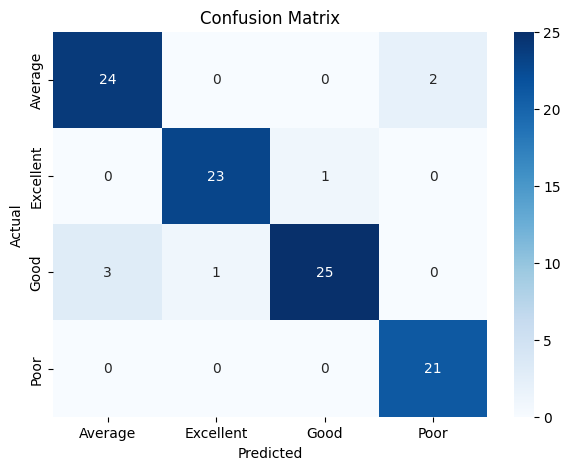

In [29]:
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Classification Report

The classification report gives precision, recall,
F1-score, and support for each class.

In [30]:
print(
    classification_report(
        y_test,
        predicted_classes,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Average       0.89      0.92      0.91        26
   Excellent       0.96      0.96      0.96        24
        Good       0.96      0.86      0.91        29
        Poor       0.91      1.00      0.95        21

    accuracy                           0.93       100
   macro avg       0.93      0.94      0.93       100
weighted avg       0.93      0.93      0.93       100



## Predict a New Student

Now we test the model with a new student's details.

Example:

- Study Hours = 6
- Attendance = 85%
- Previous GPA = 8.0
- Exam Score = 75

In [31]:
new_student = np.array([
    [6.0, 85.0, 8.0, 75.0]
])

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(
    new_student_scaled,
    verbose=0
)

predicted_class = np.argmax(
    prediction,
    axis=1
)

predicted_performance = label_encoder.inverse_transform(
    predicted_class
)[0]

print("Predicted Performance:", predicted_performance)

Predicted Performance: Good


## Prediction Probabilities

The ANN gives a probability for every performance class.

The class with the highest probability becomes the final prediction.

In [32]:
probabilities = prediction[0]

for class_name, probability in zip(
    label_encoder.classes_,
    probabilities
):
    print(f"{class_name}: {probability:.4f}")

Average: 0.0039
Excellent: 0.0018
Good: 0.9944
Poor: 0.0000


## Save the Trained ANN Model

We save the trained model so that we can use it later
in our Streamlit application without training it again.

In [33]:
model.save("student_performance_ann.keras")

print("ANN model saved successfully!")

ANN model saved successfully!


## Save the Scaler

The same scaler used during training must be used
when a new student gives input in the Streamlit application.

In [34]:
joblib.dump(
    scaler,
    "student_scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


## Save the Label Encoder

We save the label encoder because the Streamlit application
needs it to convert the predicted number back into the
original performance level.

In [35]:
joblib.dump(
    label_encoder,
    "student_label_encoder.pkl"
)

print("Label encoder saved successfully!")

Label encoder saved successfully!


## Save Selected Features

We save the four feature names used by our ANN model.

In [36]:
joblib.dump(
    selected_features,
    "selected_features.pkl"
)

print("Selected Features:")
print(selected_features)

Selected Features:
['daily_study_hours', 'attendance_percent', 'study_efficiency', 'exam_score']


# Project Conclusion

In this project, we built an Artificial Neural Network to
predict student performance.

We used four features:

- Study Hours
- Attendance
- Previous GPA
- Exam Score

We performed data preprocessing, target encoding,
feature scaling, ANN model building, training,
evaluation, prediction, and model saving.

The trained model can now be used in a Streamlit application.